In [36]:
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import numpy as np
from scipy.spatial.distance import pdist,cdist, squareform
from sklearn.metrics import silhouette_score, adjusted_rand_score
import random
import umap
from sklearn.decomposition import KernelPCA

SEED = 5
random.seed(SEED)

# loading the 50-dimensional PCA of the PBMC3k dataset - our ground dataset
adata = sc.datasets.pbmc3k_processed()
X = adata.obsm["X_pca"]
print(X.shape)

(2638, 50)


In [ ]:
### creating the impostor
n = int(len(X))
C = 20000000
D_squared = cdist(X,X, metric='sqeuclidean')
D_squared_impostor = D_squared + C*(np.ones((n,n)) - np.eye(n)) 
D_squared_impostor /= np.max(D_squared_impostor)
H = np.eye(n) - np.ones((n,n)) / n

X_impostor = KernelPCA(n_components=n-1, kernel='precomputed', random_state=SEED).fit_transform( - H @ D_squared_impostor @ H / 2.0 )

In [38]:
print('error incurred by kernel PCA is quite small:', np.sum(cdist(X_impostor, X_impostor, metric='sqeuclidean') - D_squared_impostor)**2 / np.sum(D_squared_impostor**2)   )

error incurred by kernel PCA is quite small: 7.000607479752325e-26


In [40]:
### run t-SNE and PCA on the impostor and the original dataset

pca = PCA(n_components=2, random_state=SEED)
tsne = TSNE(n_components=2, random_state=SEED)

X_pca = pca.fit_transform(X) # pca(X, noise_scale=0.01)#
X_tsne = tsne.fit_transform(X)

X_pca_impostor =  pca.fit_transform(X_impostor) #pca(X_impostor, noise_scale=0.01)
X_tsne_impostor = tsne.fit_transform(X_impostor)

In [41]:
## getting the DBSCAN clustering based on the t-SNE plot, using this as our reference labelling
db = DBSCAN(eps=5, min_samples=50).fit(X_tsne)
labels = db.labels_  # cluster labels, -1 means noise

order = np.argsort(labels)
X_reordered = X[order]
X_impostor_reordered = X_impostor[order]

In [42]:
orig_ss = silhouette_score(X, labels)
blownup_ss = silhouette_score(X_impostor, labels)

tsne_ss = silhouette_score(X_tsne, labels)
tsne_blownup_ss = silhouette_score(X_tsne_impostor, labels)

pca_ss = silhouette_score(X_pca, labels)
pca_blownup_ss = silhouette_score(X_pca_impostor, labels)

print('Silhouette of DBSCAN on original \t\t\t', orig_ss)
print('Silhouette of DBSCAN on transformed \t\t\t',blownup_ss)
print()
print('Silhouette of DBSCAN on t-sne \t\t\t\t', tsne_ss)
print('Silhouette of DBSCAN on t-sne of trx \t\t\t', tsne_blownup_ss)
print()
print('Silhouette of DBSCAN on pca \t\t\t\t', pca_ss)
print('Silhouette of DBSCAN on pca of trx \t\t\t', pca_blownup_ss)

Silhouette of DBSCAN on original 			 0.17723818
Silhouette of DBSCAN on transformed 			 2.912358928542258e-06

Silhouette of DBSCAN on t-sne 				 0.67275006
Silhouette of DBSCAN on t-sne of trx 			 0.7296779

Silhouette of DBSCAN on pca 				 0.5222317
Silhouette of DBSCAN on pca of trx 			 -0.02974926370669557


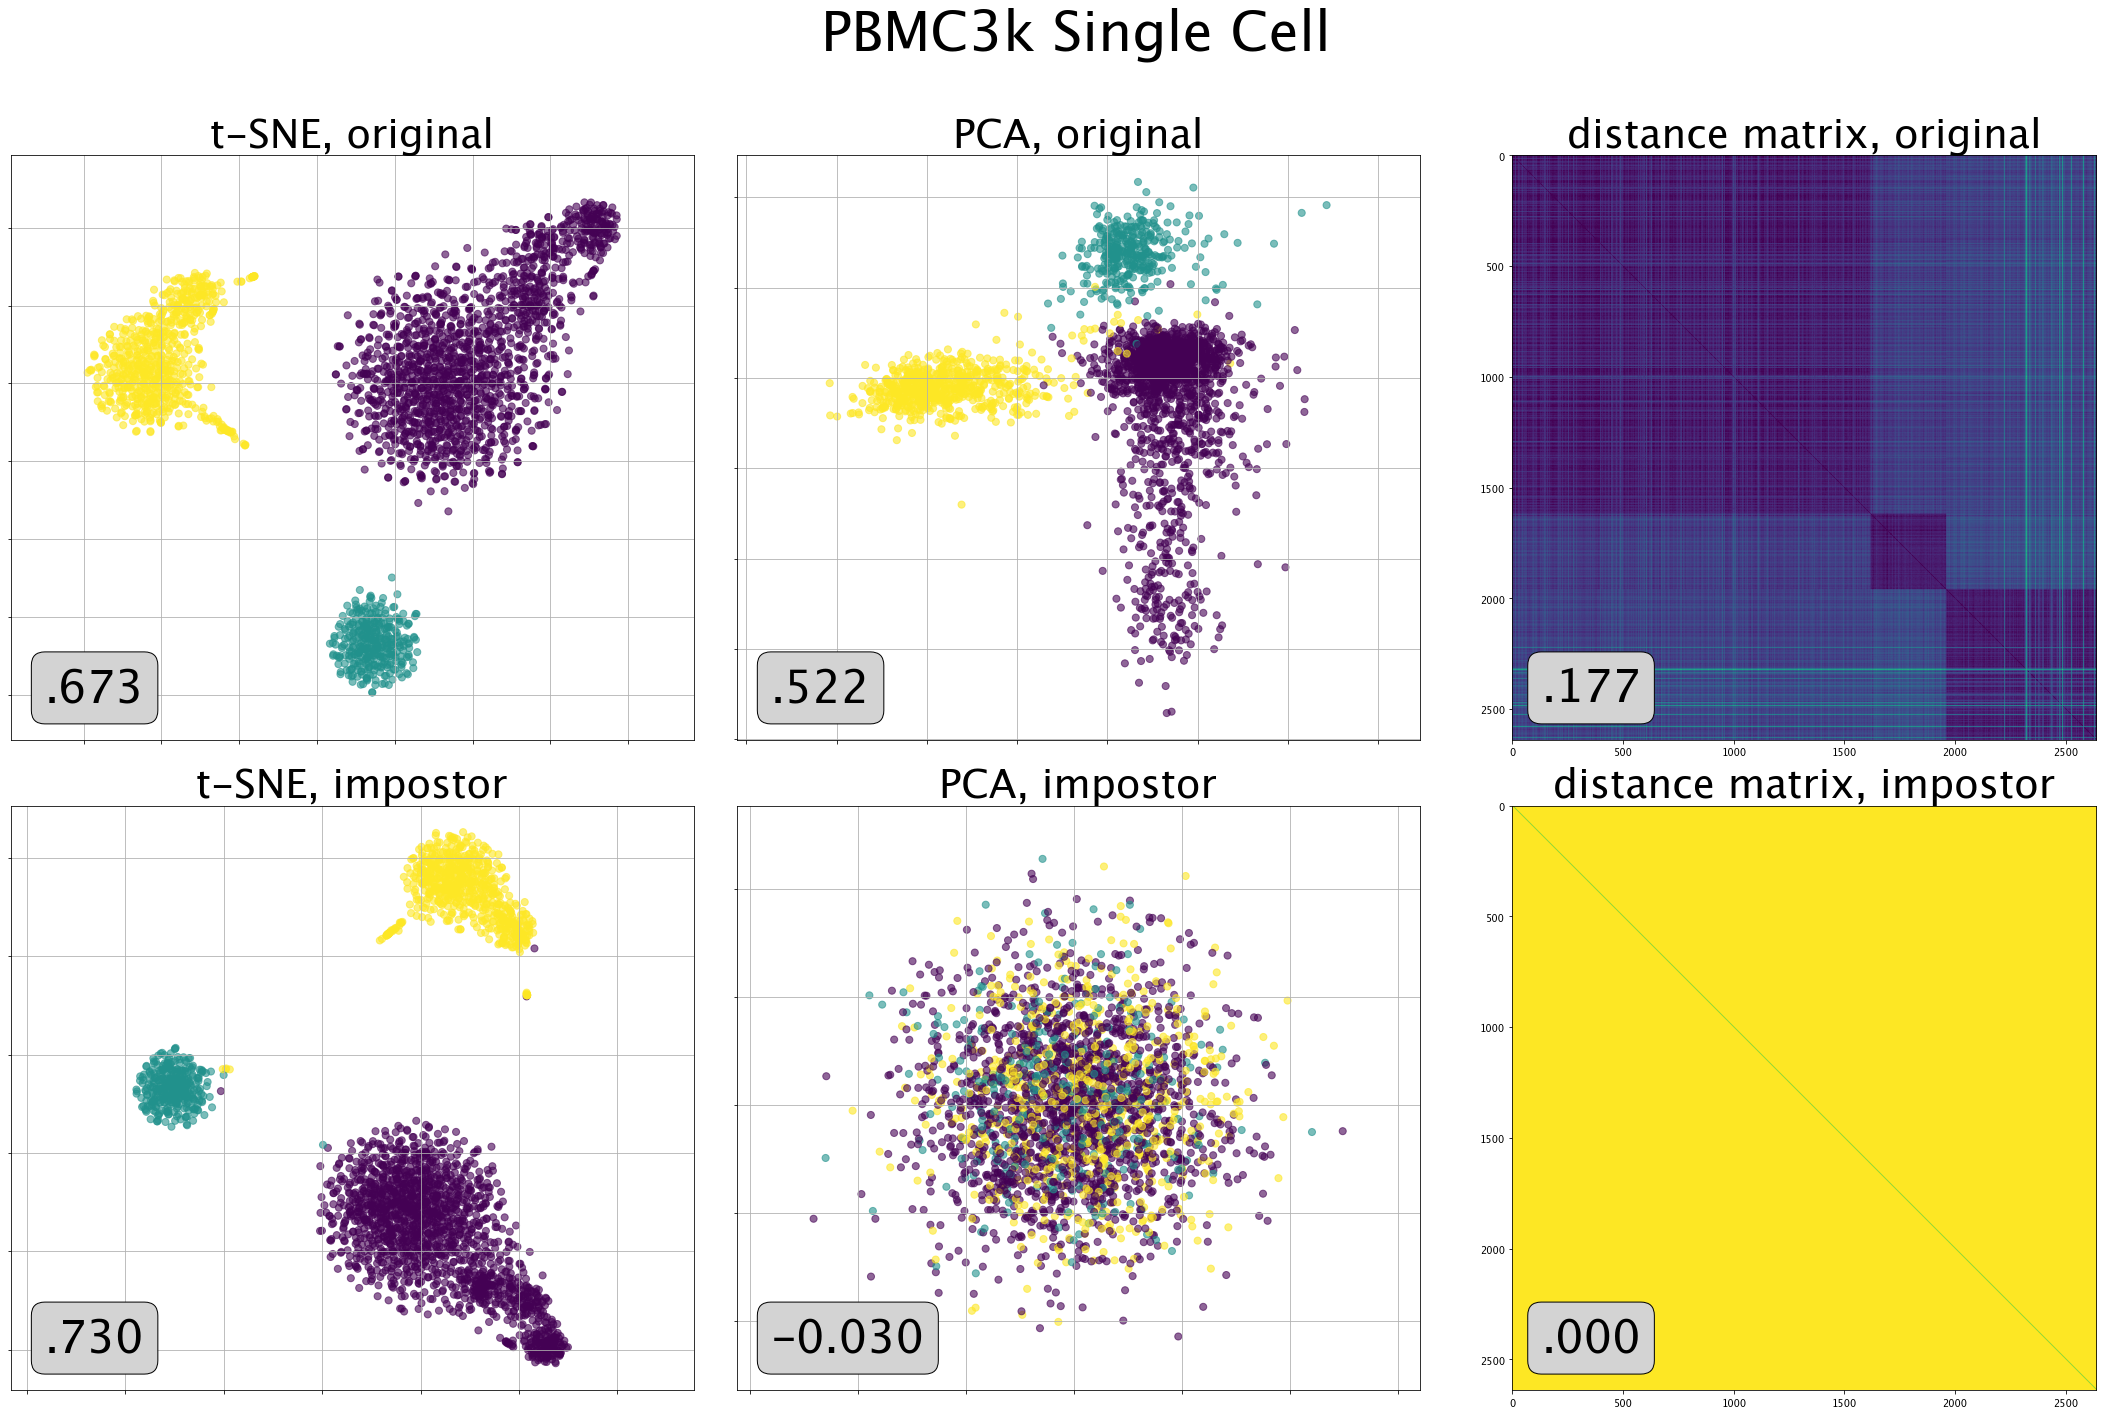

In [43]:
fig, axs = plt.subplots(2,3, figsize=(30,20))

#cmap = mcolors.ListedColormap(["purple", "green", "blue"])

for i in range(2):
    for j in range(2):
        axs[i,j].grid('on')
        axs[i,j].axis('equal')
        axs[i,j].set_xticklabels([])
        axs[i,j].set_yticklabels([])

axs[0,0].text(0.05, 0.05, f"{tsne_ss:.3f}".lstrip("0"),transform=axs[0,0].transAxes, 
              bbox=dict(facecolor="lightgrey", edgecolor="black", boxstyle="round,pad=0.3"),
              fontsize=45, ha="left", va="bottom")
axs[0,0].set_title('t-SNE, original', fontsize=40)
axs[0,0].scatter(-X_tsne[:, 0], X_tsne[:, 1], s=50, alpha=0.6,  c=labels)#, cmap=cmap)

axs[0,2].text(0.05, 0.05, f"{orig_ss:.3f}".lstrip("0"), transform=axs[0,2].transAxes, 
              bbox=dict(facecolor="lightgrey", edgecolor="black", boxstyle="round,pad=0.3"),
              fontsize=45, ha="left", va="bottom")
axs[0,2].set_title('distance matrix, original', fontsize=40)
axs[0,2].imshow(cdist(X_reordered, X_reordered, metric='euclidean'), vmin=13,vmax=50)

axs[0,1].text(0.05, 0.05, f"{pca_ss:.3f}".lstrip("0"),transform=axs[0,1].transAxes, 
              bbox=dict(facecolor="lightgrey", edgecolor="black", boxstyle="round,pad=0.3"),
              fontsize=45, ha="left", va="bottom")
axs[0,1].set_title('PCA, original', fontsize=40)
axs[0,1].scatter(-X_pca[:, 0], -X_pca[:, 1], s=50, alpha=0.6,  c=labels)#, cmap=cmap)



axs[1,0].text(0.05, 0.05, f"{tsne_blownup_ss:.3f}".lstrip("0"), transform=axs[1,0].transAxes, 
              bbox=dict(facecolor="lightgrey", edgecolor="black", boxstyle="round,pad=0.3"),
              fontsize=45, ha="left", va="bottom")
axs[1,0].set_title('t-SNE, impostor', fontsize=40)
axs[1,0].scatter(X_tsne_impostor[:, 0], X_tsne_impostor[:, 1], s=50, alpha=0.6,  c=labels)#, cmap=cmap)

axs[1,2].text(0.05, 0.05, f"{blownup_ss:.3f}".lstrip("0"),transform=axs[1,2].transAxes, 
              bbox=dict(facecolor="lightgrey", edgecolor="black", boxstyle="round,pad=0.3"),
              fontsize=45, ha="left", va="bottom")
axs[1,2].set_title('distance matrix, impostor', fontsize=40)
axs[1,2].imshow(cdist(X_impostor_reordered, X_impostor_reordered, metric='euclidean') ) #, vmin=vmin, vmax=vmax)

axs[1,1].text(0.05, 0.05, f"{pca_blownup_ss:.3f}".lstrip("0"), transform=axs[1,1].transAxes, 
              bbox=dict(facecolor="lightgrey", edgecolor="black", boxstyle="round,pad=0.3"),
              fontsize=45, ha="left", va="bottom")
axs[1,1].set_title('PCA, impostor', fontsize=40)
axs[1,1].scatter(X_pca_impostor[:, 0], X_pca_impostor[:, 1], s=50, alpha=0.6,  c=labels)#, cmap=cmap)

fig.suptitle('PBMC3k Single Cell\n', fontsize=55)

plt.tight_layout()
plt.savefig('visuals/1_single_cell/single_cell_main_figure.png', bbox_inches='tight')